In [1]:
#/archive dataset from Kaggle: https://www.kaggle.com/datasets/bikashkundu/can-hcrl-otids
#/road dataset: https://zenodo.org/records/10462796

In [ ]:
import pandas as pd
import numpy as np
import keras
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
#     DoS Attack (656,579) : Injecting messages of ‘0x000’ CAN ID in a short cycle.
#     Fuzzy Attack (591,990): Injecting messages of spoofed random CAN ID and DATA values.
#     Impersonation Attack (995,472): Injecting messages of Impersonating node, arbitration ID = '0x164'.
#     Attack Free State (2,369,868 ): Normal CAN messages.
   
# 'target' column doesn't specify the attacks, compute and label the values by seeing the above mentioned points 
# for each attacks which are there before applying any model. Impersonation_attacks can be said as spoofing attacks.

balanced_mix = pd.read_csv("archive/CAN_HCRL_OTIDS_B.csv") #CAN_HCRL_OTIDS_B is combined records of all four files and oversampled with SMOTE.(Balanced)
unbalanced_mix = pd.read_csv("archive/CAN_HCRL_OTIDS_UB.csv") #CAN_HCRL_OTIDS_UB is combined records of all four files.(Un-Balanced)
# attack_free = pd.read_csv("archive/dataset.csv") #normal, target column is 0
# dos_attacks = pd.read_csv("archive/dataset1.csv") #dos attack,  target column as 1
# fuzzy_attacks = pd.read_csv("archive/dataset2.csv") #fuzzy attack target column as 2
# impersonation_attacks = pd.read_csv("archive/dataset3.csv") #impersonation attacks, target column as 3. 

In [ ]:
balanced_mix = balanced_mix.fillna(0)
balanced_mix["ID1_int"] = balanced_mix["ID1"].apply(lambda x: int(str(x), 16))
encoder = LabelEncoder()
balanced_mix["ID1"] = encoder.fit_transform(balanced_mix["ID1"].astype(str))

In [ ]:
X_raw = balanced_mix.drop(columns=["target"])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X = np.array(X_scaled).reshape(-1, X_scaled.shape[1], 1)
y = balanced_mix["target"].values

In [ ]:
def create_sequences(X, y, window_size):
    sequences = []
    labels = []
    for i in range(len(X) - window_size):
        sequences.append(X[i:i+window_size])
        labels.append(y[i+window_size])  # label of the last message in the window
    return np.array(sequences), np.array(labels)
# Example: 8 message window
window_size = 8
X_seq, y_seq = create_sequences(X, y, window_size)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.15, stratify=y_seq
)
y_train_cat = to_categorical(y_train) #one-hot encode labels
y_test_cat = to_categorical(y_test)

In [ ]:
print(X_train.shape)

(7230348, 8, 11, 1)


In [100]:
#start with basic sequential model: 
def create_model():
    model = keras.Sequential()
    model.add(layers.Input(shape=(8, 11)))
    model.add(layers.Conv1D(16, 4, activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(4, activation='softmax'))#output layer will be 4 bc we have 4 potential classifications: normal, DOS attack, Fuzzy Attack, & Impersonation Attack
    return model

model = create_model()

In [ ]:
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/best_model_cnn.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=1, verbose=1, restore_best_weights=True)
]
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.fit(X_train, y_train_cat, batch_size = b_size, epochs = 3, validation_split=0.2, callbacks = callbacks, verbose = 1)

Epoch 1/3
 35979/180759 ━━━━━━━━━━━━━━━━━━━━ 6:41 3ms/step - accuracy: 0.6892 - loss: 0.7734

In [94]:
testing_acc = model.evaluate(X_test,y_test_cat, verbose=1)
print(f"Test loss: {testing_acc[0]}")
print(f"Test accuracy: {testing_acc[1]}")

39874/39874 ━━━━━━━━━━━━━━━━━━━━ 30s 763us/step - accuracy: 0.6962 - loss: 0.7682
Test loss: 0.7681623101234436
Test accuracy: 0.6961966753005981


In [95]:
#examine classification predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)       
y_true = np.argmax(y_test_cat, axis=1) 
print(classification_report(y_true, y_pred, target_names=["Normal", "DoS", "Fuzzy", "Impersonation"]))

39874/39874 ━━━━━━━━━━━━━━━━━━━━ 26s 641us/step
               precision    recall  f1-score   support

       Normal       0.49      0.71      0.58    318986
          DoS       0.83      0.72      0.77    318986
        Fuzzy       0.79      0.76      0.77    318986
Impersonation       0.82      0.60      0.69    318986

     accuracy                           0.70   1275944
    macro avg       0.73      0.70      0.70   1275944
 weighted avg       0.73      0.70      0.70   1275944



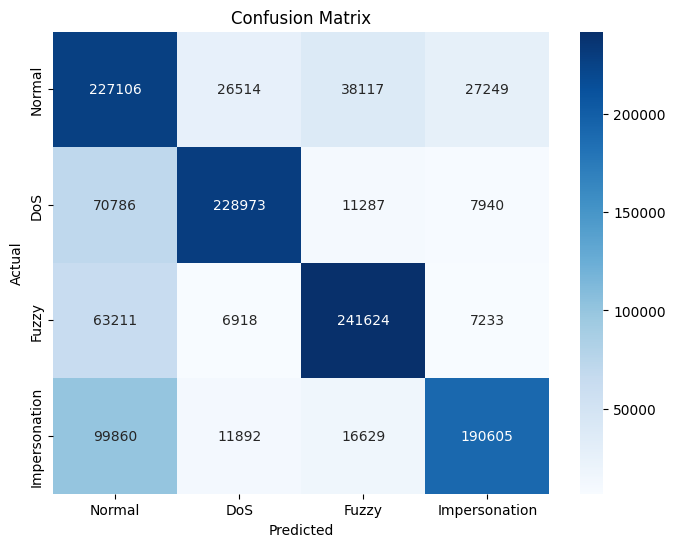

In [96]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "DoS", "Fuzzy", "Impersonation"],
            yticklabels=["Normal", "DoS", "Fuzzy", "Impersonation"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()